# Exploratory Data Analysis (EDA)

## Objective
Explore the Corporación Favorita Store Sales dataset to:
1. Understand data structure and quality
2. Identify patterns, trends, and seasonality
3. Select appropriate scope (store + product family) for modeling
4. Assess the impact of promotions on sales
5. Identify any data quality issues

## Approach
- Load and inspect the dataset
- Perform global analysis to select scope
- Conduct detailed time series analysis on selected scope
- Document findings for feature engineering and modeling decisions

In [1]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Import project modules
import src.config as config
from src.utils import (
    load_and_prepare_data, 
    print_section_header, 
    describe_dataframe,
    get_date_features
)
from src.eda import (
    plot_time_series,
    plot_rolling_averages,
    plot_seasonality,
    plot_promotion_effect,
    time_series_decomposition,
    plot_sales_distribution,
    top_stores_and_families,
    correlation_analysis
)

# Set random seed for reproducibility
np.random.seed(config.RANDOM_SEED)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Environment setup complete!")

Environment setup complete!


## 1. Data Loading & Inspection

In [2]:
# Load training data
train_df = load_and_prepare_data(config.TRAIN_FILE, date_col='date')

# Display first few rows
print("\nFirst 10 rows:")
train_df.head(10)

Data loaded: 3000888 rows, 6 columns
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00

First 10 rows:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [3]:
# Describe the dataset
describe_dataframe(train_df, name="Training Data")


 Training Data Summary

Shape: 3000888 rows × 6 columns

Column types:
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

Memory usage: 308.39 MB

Missing values:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []
No missing values found.


In [4]:
# Check basic statistics
print_section_header("Summary Statistics")
train_df.describe()


 Summary Statistics



,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [5]:
# Check for unique values
print_section_header("Unique Values")
print(f"Number of unique stores: {train_df['store_nbr'].nunique()}")
print(f"Number of unique product families: {train_df['family'].nunique()}")
print(f"Date range: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Total days: {(train_df['date'].max() - train_df['date'].min()).days + 1}")

print("\nProduct families:")
print(train_df['family'].unique())


 Unique Values

Number of unique stores: 54
Number of unique product families: 33
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Total days: 1688

Product families:
<StringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET

In [6]:
# Check for anomalies in sales (negative values, extreme outliers)
print_section_header("Sales Value Analysis")
print(f"Minimum sales: {train_df['sales'].min()}")
print(f"Maximum sales: {train_df['sales'].max()}")
print(f"Mean sales: {train_df['sales'].mean():.2f}")
print(f"Median sales: {train_df['sales'].median():.2f}")
print(f"\nRows with zero sales: {(train_df['sales'] == 0).sum()} ({100 * (train_df['sales'] == 0).sum() / len(train_df):.2f}%)")
print(f"Rows with negative sales: {(train_df['sales'] < 0).sum()}")


 Sales Value Analysis

Minimum sales: 0.0
Maximum sales: 124717.0
Mean sales: 357.78
Median sales: 11.00

Rows with zero sales: 939130 (31.30%)
Rows with negative sales: 0


## 2. Global EDA (Before Subsetting)

Analyze overall patterns to inform scope selection.

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\01_global_sales_distribution.png


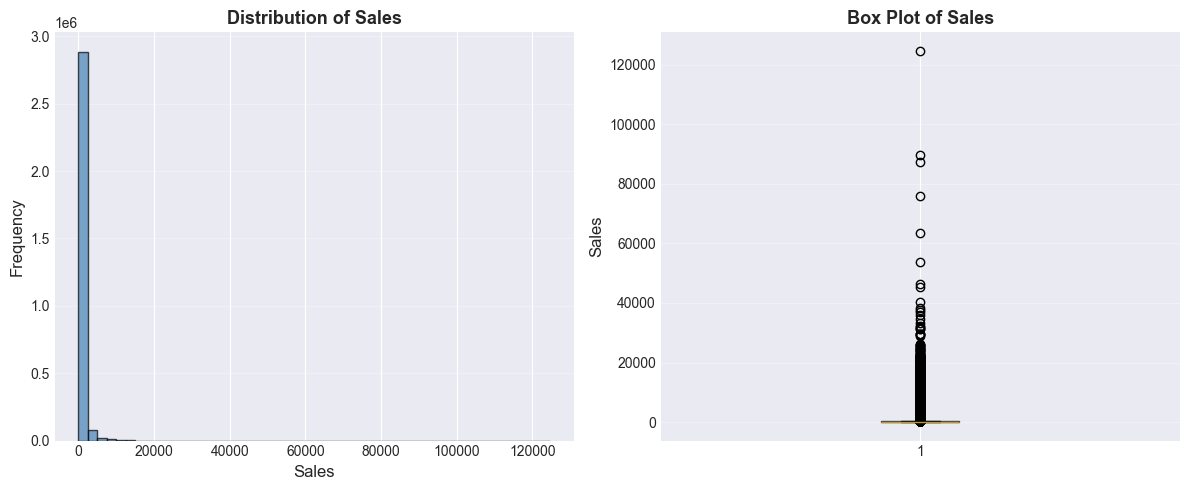

In [7]:
# Plot sales distribution
plot_sales_distribution(train_df, value_col='sales', save_filename='01_global_sales_distribution.png')
plt.show()

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\02_top_stores.png


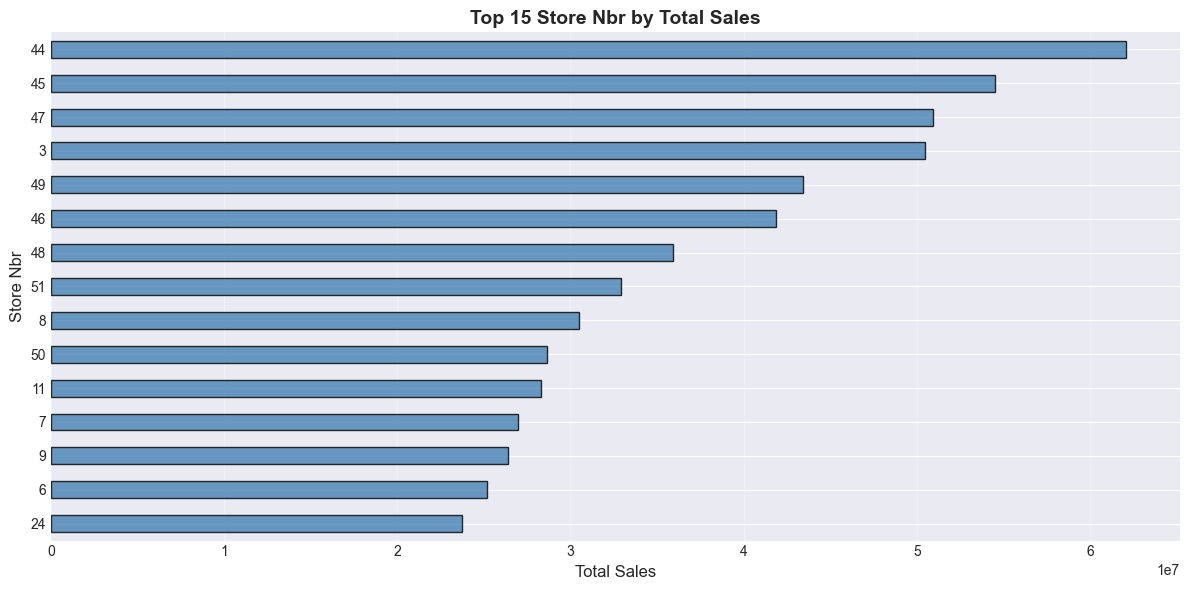


Top 15 stores by total sales:
                  sales
store_nbr              
44         6.208755e+07
45         5.449801e+07
47         5.094831e+07
3          5.048191e+07
49         4.342010e+07
46         4.189606e+07
48         3.593313e+07
51         3.291149e+07
8          3.049429e+07
50         2.865302e+07
11         2.832556e+07
7          2.695205e+07
9          2.640944e+07
6          2.518368e+07
24         2.376773e+07


In [8]:
# Top stores by total sales
fig, top_stores = top_stores_and_families(
    train_df, 
    group_col='store_nbr', 
    top_n=15,
    save_filename='02_top_stores.png'
)
plt.show()

print("\nTop 15 stores by total sales:")
print(top_stores)

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\03_top_families.png


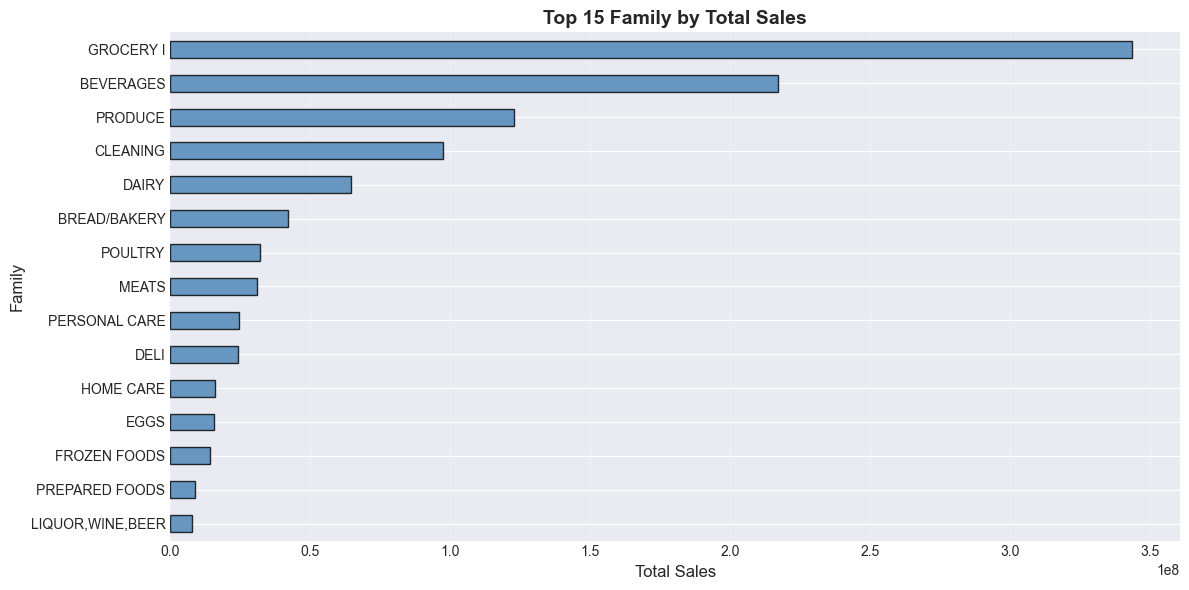


Top 15 product families by total sales:
                         sales
family                        
GROCERY I         3.434627e+08
BEVERAGES         2.169545e+08
PRODUCE           1.227047e+08
CLEANING          9.752129e+07
DAIRY             6.448771e+07
BREAD/BAKERY      4.213395e+07
POULTRY           3.187600e+07
MEATS             3.108647e+07
PERSONAL CARE     2.459205e+07
DELI              2.411032e+07
HOME CARE         1.602274e+07
EGGS              1.558830e+07
FROZEN FOODS      1.407389e+07
PREPARED FOODS    8.799895e+06
LIQUOR,WINE,BEER  7.746640e+06


In [9]:
# Top product families by total sales
fig, top_families = top_stores_and_families(
    train_df, 
    group_col='family', 
    top_n=15,
    save_filename='03_top_families.png'
)
plt.show()

print("\nTop 15 product families by total sales:")
print(top_families)

## 3. Scope Selection

**Decision Criteria:**
- High sales volume (good signal-to-noise ratio)
- Clear patterns in time series
- Single store and family to keep analysis focused

**Selection:**
- Based on the analysis above, we'll select a top-performing store and family
- Let's choose **Store 44** (one of the top stores) and **GROCERY I** (top family)

In [10]:
# Select scope - modify these based on EDA findings
SELECTED_STORE = 44
SELECTED_FAMILY = 'GROCERY I'

print(f"Selected Scope:")
print(f"  Store: {SELECTED_STORE}")
print(f"  Family: {SELECTED_FAMILY}")

# Filter data
scope_df = train_df[
    (train_df['store_nbr'] == SELECTED_STORE) & 
    (train_df['family'] == SELECTED_FAMILY)
].copy()

print(f"\nFiltered data shape: {scope_df.shape}")
print(f"Date range: {scope_df['date'].min()} to {scope_df['date'].max()}")

Selected Scope:
  Store: 44
  Family: GROCERY I

Filtered data shape: (1684, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


In [11]:
# Aggregate to daily level (in case of duplicates) and ensure continuous date index
daily_sales = scope_df.groupby('date').agg({
    'sales': 'sum',
    'onpromotion': 'sum'
}).reset_index()

# Create complete date range
date_range = pd.date_range(start=daily_sales['date'].min(), 
                           end=daily_sales['date'].max(), 
                           freq='D')

# Reindex to ensure all dates are present
daily_sales = daily_sales.set_index('date').reindex(date_range, fill_value=0).reset_index()
daily_sales.columns = ['date', 'sales', 'onpromotion']

print(f"Daily aggregated data shape: {daily_sales.shape}")
print(f"\nSample:")
print(daily_sales.head(10))

Daily aggregated data shape: (1688, 3)

Sample:
        date    sales  onpromotion
0 2013-01-01      0.0            0
1 2013-01-02  10686.0            0
2 2013-01-03   7342.0            0
3 2013-01-04   7250.0            0
4 2013-01-05  10699.0            0
5 2013-01-06  12373.0            0
6 2013-01-07   7059.0            0
7 2013-01-08  19849.0            0
8 2013-01-09   7546.0            0
9 2013-01-10   5101.0            0


## 4. Scoped Time Series Analysis

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\04_daily_sales_timeseries.png


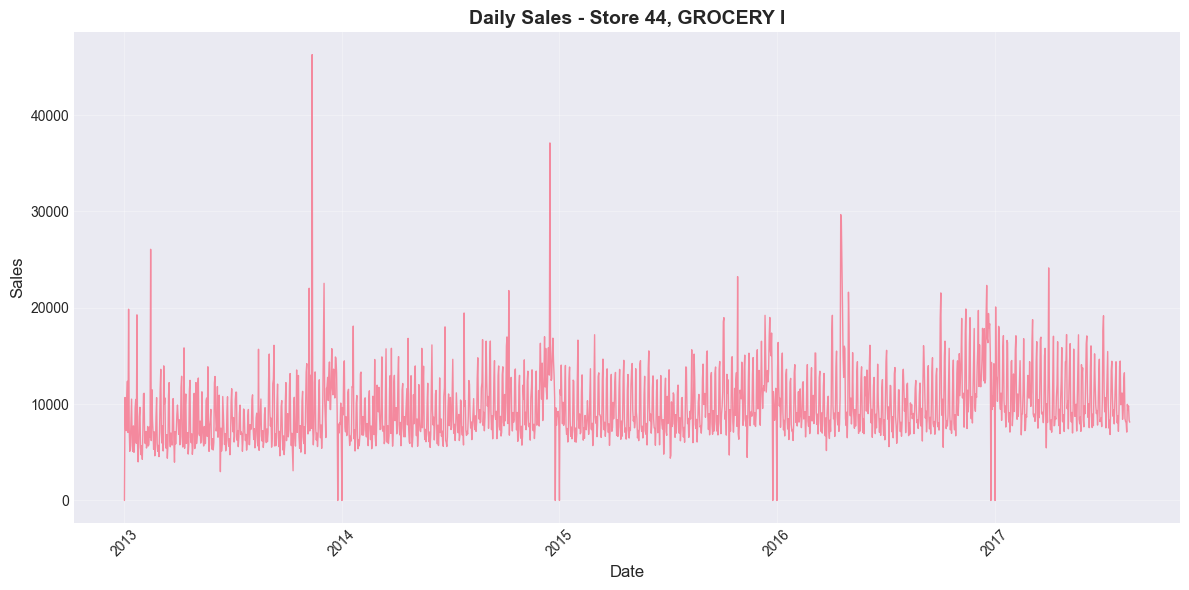

In [12]:
# Plot full time series
plot_time_series(
    daily_sales, 
    date_col='date', 
    value_col='sales',
    title=f'Daily Sales - Store {SELECTED_STORE}, {SELECTED_FAMILY}',
    save_filename='04_daily_sales_timeseries.png'
)
plt.show()

## 5. Trend & Seasonality Analysis

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\05_rolling_averages.png


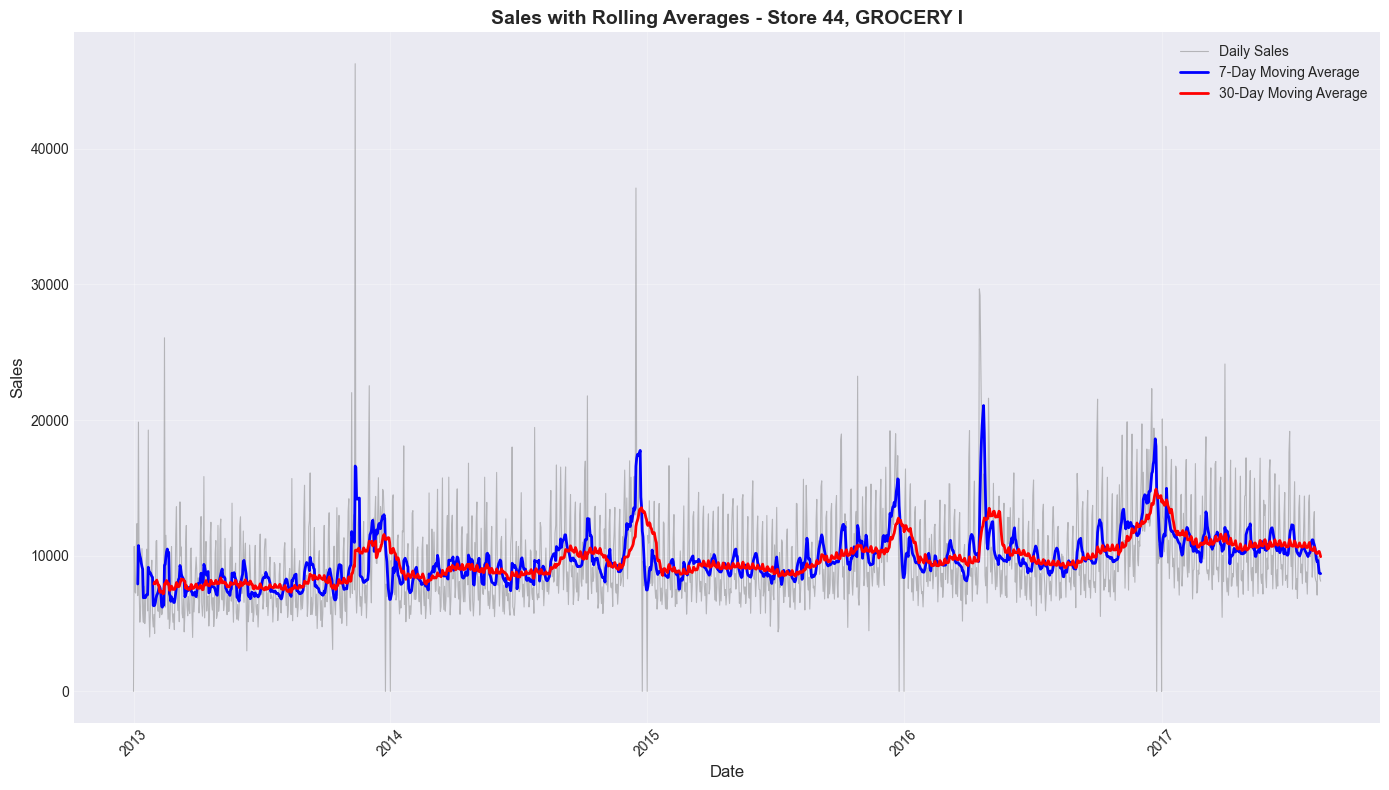

In [13]:
# Plot with rolling averages
plot_rolling_averages(
    daily_sales,
    date_col='date',
    value_col='sales',
    windows=[7, 30],
    title=f'Sales with Rolling Averages - Store {SELECTED_STORE}, {SELECTED_FAMILY}',
    save_filename='05_rolling_averages.png'
)
plt.show()

In [14]:
# Add date features for seasonality analysis
daily_sales_with_features = daily_sales.copy()
date_features = get_date_features(daily_sales_with_features['date'])
daily_sales_with_features = pd.concat([daily_sales_with_features, date_features], axis=1)

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\06_weekly_seasonality.png


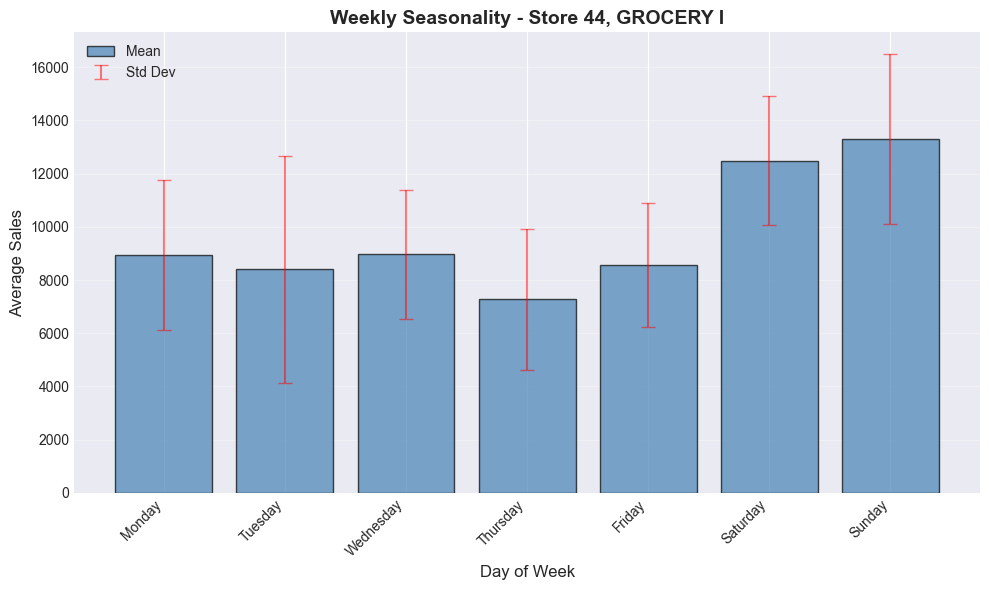

In [15]:
# Average sales by day of week
plot_seasonality(
    daily_sales_with_features,
    value_col='sales',
    groupby='day_of_week',
    title=f'Weekly Seasonality - Store {SELECTED_STORE}, {SELECTED_FAMILY}',
    save_filename='06_weekly_seasonality.png'
)
plt.show()

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\07_monthly_seasonality.png


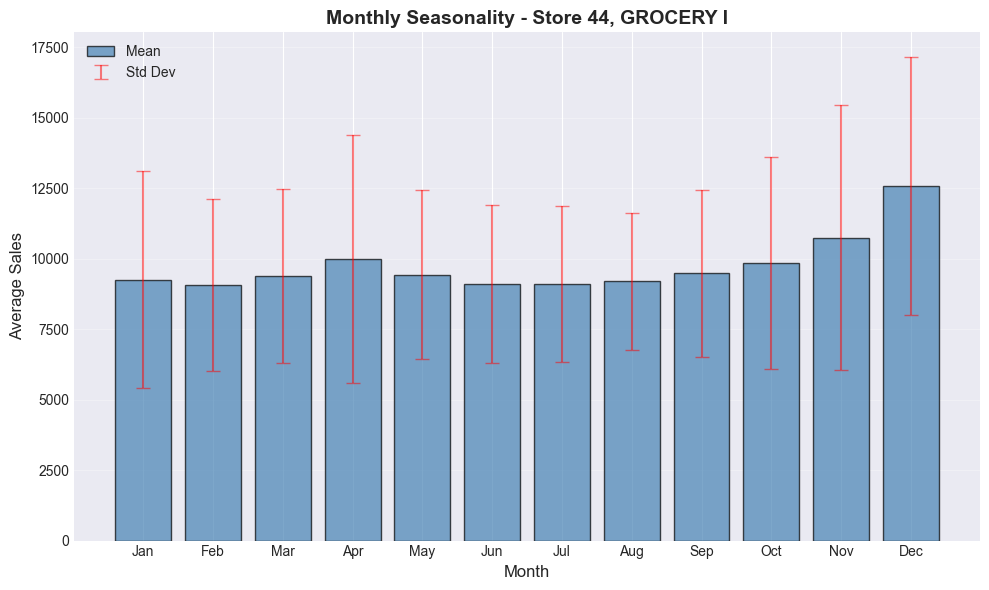

In [16]:
# Average sales by month
plot_seasonality(
    daily_sales_with_features,
    value_col='sales',
    groupby='month',
    title=f'Monthly Seasonality - Store {SELECTED_STORE}, {SELECTED_FAMILY}',
    save_filename='07_monthly_seasonality.png'
)
plt.show()

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\08_decomposition.png


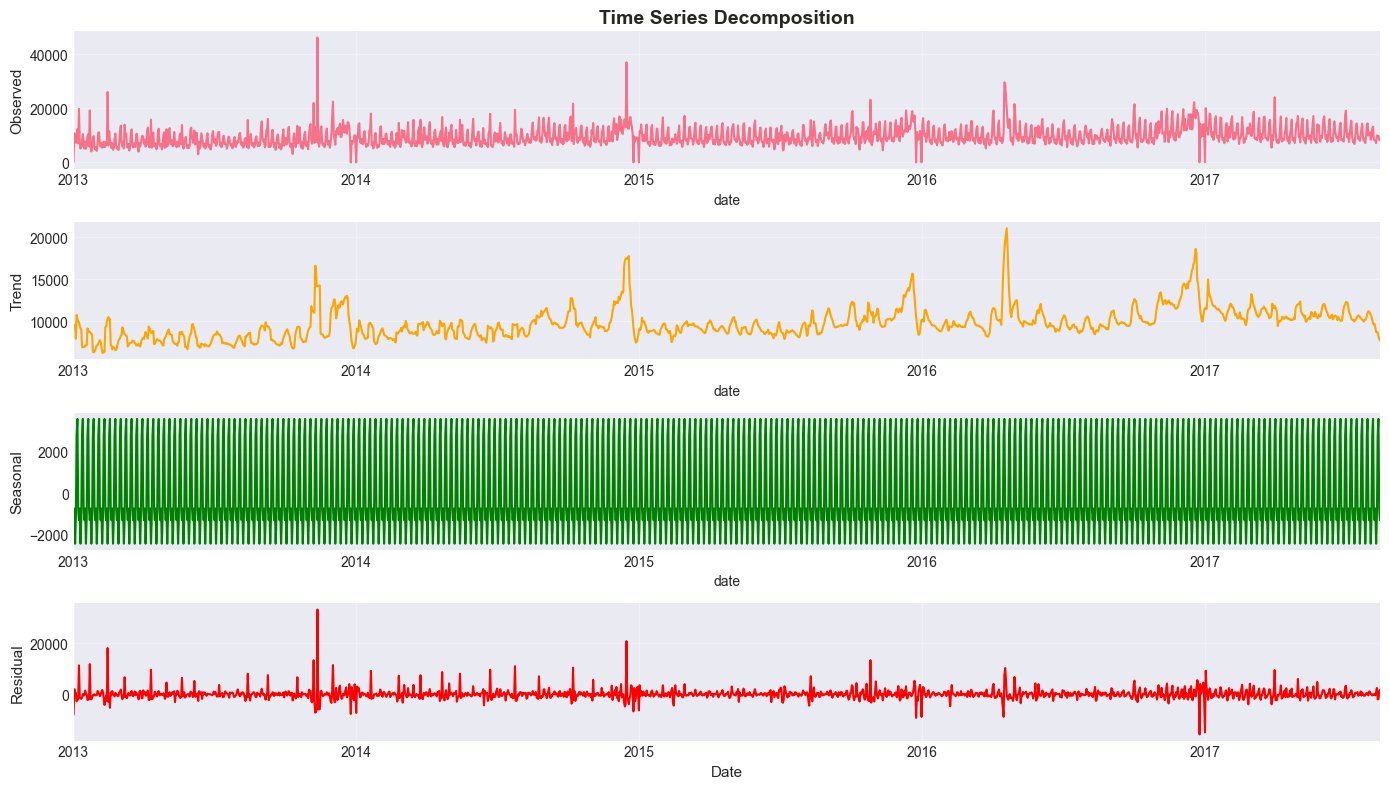

In [17]:
# Time series decomposition
# Create series with datetime index
sales_series = daily_sales.set_index('date')['sales']

fig, decomposition = time_series_decomposition(
    sales_series,
    freq=7,
    model='additive',
    save_filename='08_decomposition.png'
)
plt.show()

## 6. Promotions Analysis

Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\09_promotion_effect.png


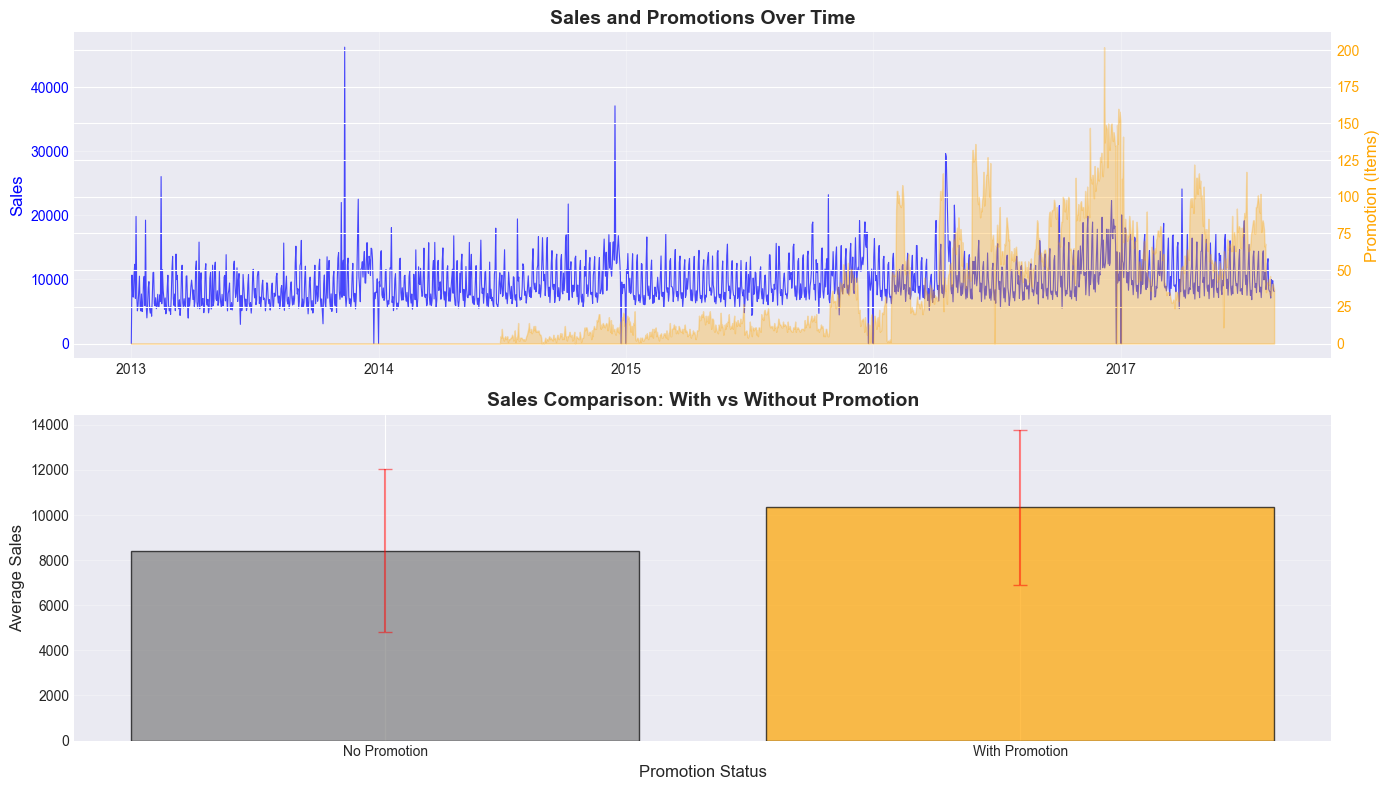

In [18]:
# Plot promotion effect
plot_promotion_effect(
    daily_sales,
    date_col='date',
    sales_col='sales',
    promo_col='onpromotion',
    save_filename='09_promotion_effect.png'
)
plt.show()

In [19]:
# Correlation between promotions and sales
print_section_header("Promotion Impact Analysis")

# Overall statistics
promo_stats = daily_sales.groupby(daily_sales['onpromotion'] > 0)['sales'].describe()
print("\nSales statistics by promotion status:")
print(promo_stats)

# Correlation
correlation = daily_sales[['sales', 'onpromotion']].corr().iloc[0, 1]
print(f"\nCorrelation between sales and promotion: {correlation:.4f}")

# Percentage increase
no_promo_mean = daily_sales[daily_sales['onpromotion'] == 0]['sales'].mean()
promo_mean = daily_sales[daily_sales['onpromotion'] > 0]['sales'].mean()
pct_increase = ((promo_mean - no_promo_mean) / no_promo_mean) * 100

print(f"\nAverage sales without promotion: {no_promo_mean:.2f}")
print(f"Average sales with promotion: {promo_mean:.2f}")
print(f"Percentage increase: {pct_increase:.2f}%")

print("\n✓ Decision: Include 'onpromotion' as a feature in modeling")


 Promotion Impact Analysis


Sales statistics by promotion status:
              count          mean          std     min     25%     50%  \
onpromotion                                                              
False         555.0   8418.009009  3615.619315     0.0  6204.5  7368.0   
True         1133.0  10338.976203  3425.606337  4390.0  7886.0  9156.0   

                 75%      max  
onpromotion                    
False        10489.5  46271.0  
True         12453.0  37106.0  

Correlation between sales and promotion: 0.2762

Average sales without promotion: 8418.01
Average sales with promotion: 10338.98
Percentage increase: 22.82%

✓ Decision: Include 'onpromotion' as a feature in modeling


Figure saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\figures\10_correlation_matrix.png


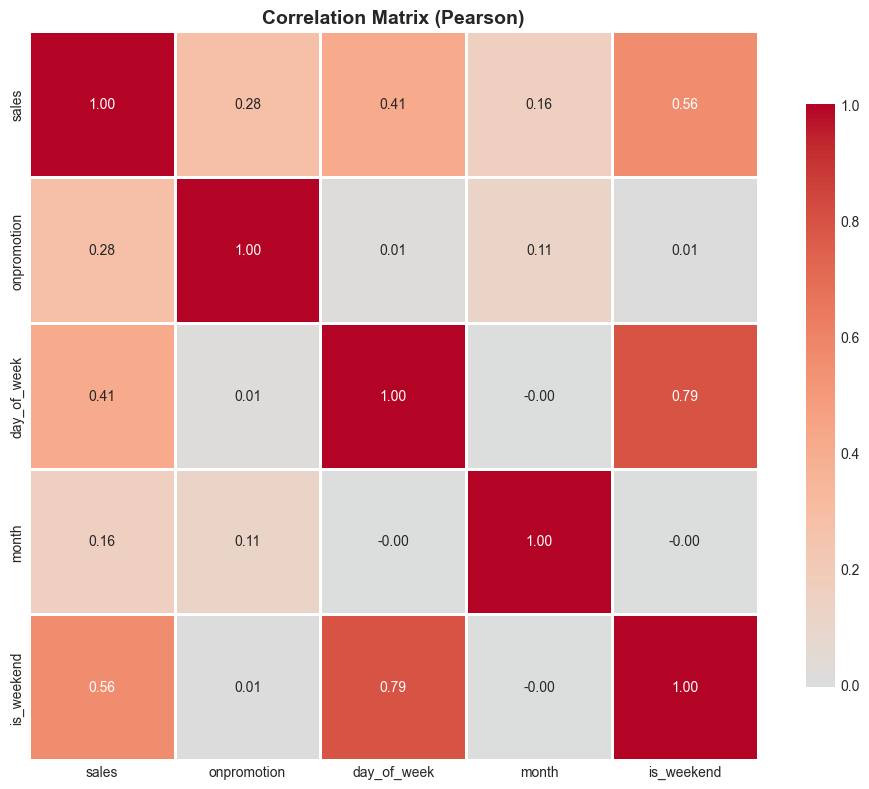


Correlation with sales:
sales          1.000000
is_weekend     0.559016
day_of_week    0.412503
onpromotion    0.276233
month          0.160686
Name: sales, dtype: float64


In [20]:
# Create correlation heatmap with additional features
corr_features = ['sales', 'onpromotion', 'day_of_week', 'month', 'is_weekend']
fig, corr_matrix = correlation_analysis(
    daily_sales_with_features,
    columns=corr_features,
    method='pearson',
    save_filename='10_correlation_matrix.png'
)
plt.show()

print("\nCorrelation with sales:")
print(corr_matrix['sales'].sort_values(ascending=False))

## 7. Summary Findings

### Key Observations:

1. **Data Quality:**
   - Dataset contains ~3 million rows with complete date coverage
   - No missing values in core columns
   - Some zero sales days (expected for retail)

2. **Scope Selection:**
   - Selected Store 44 and GROCERY I family
   - Both are high-volume, providing good signal for modeling
   - Dataset spans multiple years for robust time series analysis

3. **Trend:**
   - Time series shows clear trend component (visible in decomposition)
   - Rolling averages reveal underlying patterns beyond daily noise

4. **Seasonality:**
   - **Weekly seasonality**: Strong day-of-week patterns evident
   - **Monthly seasonality**: Some variation across months
   - Decomposition confirms additive seasonality pattern

5. **Promotions:**
   - Promotions show positive correlation with sales
   - Clear uplift in sales during promotional periods
   - Will include as exogenous variable in modeling

6. **Outliers:**
   - Some spikes visible in the time series (holidays, special events)
   - Residuals show some extreme values
   - May need robust modeling approaches

### Implications for Modeling:

- **Feature Engineering**: Create lag features, rolling statistics, calendar features
- **Modeling Approach**: 
  - SARIMA/SARIMAX for statistical approach (weekly seasonality, period=7)
  - ML models (RandomForest/GradientBoosting) for non-linear patterns
- **Validation Strategy**: Time series split (no shuffling)
- **Exogenous Variables**: Include promotions, day of week, month
- **Handle Outliers**: Monitor residuals, consider robust loss functions

### Next Steps:
1. Create time-aware train/test split
2. Engineer features with proper lag handling
3. Build baseline models for comparison
4. Develop and tune main forecasting models

In [21]:
# Save the processed daily sales data for next notebook
output_path = config.DATA_PATH / 'processed_daily_sales.csv'
daily_sales.to_csv(output_path, index=False)
print(f"\n✓ Processed data saved to: {output_path}")

# Save scope configuration for reproducibility
print(f"\n✓ Update config.py with:")
print(f"   SELECTED_STORE = {SELECTED_STORE}")
print(f"   SELECTED_FAMILY = '{SELECTED_FAMILY}'")


✓ Processed data saved to: C:\Users\Karla\Downloads\karla strojno\karla strojno\notebooks\..\data\processed_daily_sales.csv

✓ Update config.py with:
   SELECTED_STORE = 44
   SELECTED_FAMILY = 'GROCERY I'


---
**End of Exploratory Data Analysis**